# Module 11 — Extending scikit-learn

Sooner or later the library will not have the thing you need: a domain
transform, a business-specific model, a splitter that respects both time and
groups. The difference between a hack and a component is whether it satisfies
the contract from Module 00 — because everything else in the library (pipelines,
`clone`, `GridSearchCV`, `cross_validate`, `set_output`, persistence) is built
on that contract and nothing else.

Get it right and your custom object is a first-class citizen. Get it wrong and
it works in your notebook and fails silently inside a cross-validation loop.

### Learning objectives

1. Write a transformer, a classifier and a meta-estimator that pass
   `check_estimator`.
2. State the `__init__` rules and why `clone` depends on them.
3. Use `validate_data`, `check_is_fitted` and `__sklearn_tags__` correctly.
4. Support `get_feature_names_out` and `set_output`.
5. Write custom scorers and custom cross-validation splitters.
6. Build something genuinely useful: a Weight-of-Evidence encoder for credit
   scorecards.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])

## 1. The contract, as rules

**`__init__`**

1. Every argument is stored on `self` **under the same name, unmodified**.
2. No validation, no conversion, no computation. None.
3. Every argument has a default (except in meta-estimators, where the wrapped
   estimator is positional).
4. No `*args` / `**kwargs`.

Rules 1 and 2 exist because `clone` reconstructs your estimator by calling
`type(est)(**est.get_params())`. If `__init__` transformed its inputs, the
clone would not equal the original, and every cross-validation fold would
silently use a different object than you think.

**`fit`**

5. Validate input (`validate_data`), set `n_features_in_` and
   `feature_names_in_`.
6. Store everything learned with a **trailing underscore**.
7. Reset state — a second `fit` must behave like a fresh object.
8. `return self`.

**`transform` / `predict`**

9. Call `check_is_fitted(self)` first.
10. Validate with `reset=False`, so a feature-count or name mismatch raises.
11. Never learn anything.

In [2]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.utils.validation import check_is_fitted, validate_data


class BadTransformer(TransformerMixin, BaseEstimator):
    """Every rule broken. Study the failure, then never do it."""

    def __init__(self, columns=None, threshold=0.5):
        self.columns = list(columns) if columns else []   # BREAKS RULE 1: converts
        self.thresh = threshold                            # BREAKS RULE 1: renames
        if threshold < 0:                                  # BREAKS RULE 2: validates
            raise ValueError("threshold must be >= 0")

    def fit(self, X, y=None):
        self.mean = np.asarray(X).mean(0)                  # BREAKS RULE 6: no underscore
        return self

    def transform(self, X):
        return np.asarray(X) - self.mean                   # BREAKS RULE 9: no check_is_fitted


bad = BadTransformer(columns=("a", "b"), threshold=0.7)

try:
    print("get_params():", bad.get_params())
except AttributeError as e:
    print(f"get_params() -> {type(e).__name__}: {e}")

print("\n^ `get_params` introspects the __init__ SIGNATURE and then reads each")
print("  name off the instance. `threshold` was stored as `thresh`, so there is")
print("  nothing to read. The object cannot be cloned, cannot be tuned, cannot be")
print("  put in a Pipeline -- and none of that is visible until something tries.")

try:
    clone(bad)
except Exception as e:
    print(f"\nclone() -> {type(e).__name__}: {str(e)[:150]}")

# Fix only the renaming, and watch the next violation surface.
class LessBadTransformer(BadTransformer):
    def __init__(self, columns=None, threshold=0.5):
        self.columns = list(columns) if columns else []   # still converts
        self.threshold = threshold                         # name now matches


lb = LessBadTransformer(columns=("a", "b"))
print(f"\nafter fixing the name: get_params() = {lb.get_params()}")
try:
    clone(lb)
except Exception as e:
    print(f"clone() -> {type(e).__name__}: {str(e)[:220]}")

get_params() -> AttributeError: 'BadTransformer' object has no attribute 'threshold'

^ `get_params` introspects the __init__ SIGNATURE and then reads each
  name off the instance. `threshold` was stored as `thresh`, so there is
  nothing to read. The object cannot be cloned, cannot be tuned, cannot be
  put in a Pipeline -- and none of that is visible until something tries.

clone() -> AttributeError: 'BadTransformer' object has no attribute 'threshold'

after fixing the name: get_params() = {'columns': ['a', 'b'], 'threshold': 0.5}
clone() -> RuntimeError: Cannot clone object LessBadTransformer(columns=['a', 'b']), as the constructor either does not set or modifies parameter columns


`clone` compares the parameters it read out with the parameters of the
reconstructed object and raises when they differ. That check exists precisely
to catch this class of bug at the earliest possible moment.

### One more rule, easy to get wrong

**12. Mixins come first; `BaseEstimator` comes last.**

```python
class MyThing(TransformerMixin, BaseEstimator):   # correct
class MyThing(BaseEstimator, TransformerMixin):   # wrong -- check_estimator will say so
```

Python resolves methods left to right, and `__sklearn_tags__` is defined on
both `BaseEstimator` and every mixin. Put `BaseEstimator` first and its generic
implementation wins, so your estimator never advertises that it is a
transformer (or a classifier, or a regressor). Since 1.6 `check_estimator`
detects this and tells you exactly what to swap — but only if you run it.

## 2. A correct transformer

A **winsoriser**: clip each feature at learned percentiles. Genuinely useful —
it stops a single mis-keyed value from dominating a scaled linear model — and
small enough to show every part of the contract.

In [3]:
class Winsorizer(TransformerMixin, BaseEstimator):
    """Clip each feature to learned lower/upper percentiles.

    Parameters
    ----------
    lower : float, default=0.01
        Lower percentile, in [0, 1).
    upper : float, default=0.99
        Upper percentile, in (0, 1].
    add_indicator : bool, default=False
        If True, append a binary column per feature flagging clipped rows.

    Attributes
    ----------
    lower_bounds_ : ndarray of shape (n_features,)
    upper_bounds_ : ndarray of shape (n_features,)
    n_features_in_ : int
    feature_names_in_ : ndarray of shape (n_features,)
    """

    def __init__(self, lower=0.01, upper=0.99, add_indicator=False):
        # Rule 1 & 2: store as given, validate nothing.
        self.lower = lower
        self.upper = upper
        self.add_indicator = add_indicator

    def fit(self, X, y=None):
        # Validation belongs here, not in __init__.
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, got {self.lower}, {self.upper}")

        # Rule 5: sets n_features_in_ and feature_names_in_ for us.
        X = validate_data(self, X, dtype=np.float64, ensure_all_finite="allow-nan")

        # Rule 6: learned state gets a trailing underscore.
        self.lower_bounds_ = np.nanpercentile(X, self.lower * 100, axis=0)
        self.upper_bounds_ = np.nanpercentile(X, self.upper * 100, axis=0)
        return self                                        # Rule 8

    def transform(self, X):
        check_is_fitted(self)                              # Rule 9
        X = validate_data(self, X, dtype=np.float64, reset=False, ensure_all_finite="allow-nan")  # Rule 10
        clipped = np.clip(X, self.lower_bounds_, self.upper_bounds_)
        if self.add_indicator:
            flags = ((X < self.lower_bounds_) | (X > self.upper_bounds_)).astype(np.float64)
            clipped = np.hstack([clipped, flags])
        return clipped

    def get_feature_names_out(self, input_features=None):
        from sklearn.utils.validation import _check_feature_names_in

        names = _check_feature_names_in(self, input_features)
        if self.add_indicator:
            names = np.concatenate([names, [f"{n}_clipped" for n in names]])
        return np.asarray(names, dtype=object)

    def __sklearn_tags__(self):
        # Declare what this estimator can handle. The base class fills in the
        # rest; you only override what differs.
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        return tags

In [4]:
num = X.select_dtypes(include=np.number)
w = Winsorizer(lower=0.02, upper=0.98, add_indicator=True).set_output(transform="pandas")
out = w.fit_transform(num)

print("params round-trip cleanly:", clone(w).get_params() == w.get_params())
print("feature_names_in_ :", w.feature_names_in_[:4], "...")
print("output columns    :", list(out.columns[-4:]))
print()
pd.DataFrame({
    "raw_max": num.max(),
    "clipped_max": out[num.columns].max(),
    "rows_clipped": out[[f"{c}_clipped" for c in num.columns]].sum().to_numpy(),
}).round(1)

params round-trip cleanly: True
feature_names_in_ : ['age' 'employment_years' 'annual_income' 'loan_amount'] ...
output columns    : ['debt_to_income_clipped', 'credit_score_clipped', 'n_open_accounts_clipped', 'n_delinq_2yr_clipped']



,raw_max,clipped_max,rows_clipped
age,85.0,69.0,403.0
employment_years,45.0,19.3,359.0
annual_income,216900.0,88706.0,463.0
loan_amount,120000.0,56704.0,480.0
term_months,60.0,60.0,0.0
interest_rate,22.8,18.5,475.0
debt_to_income,1.4,1.0,479.0
credit_score,844.0,754.2,425.0
n_open_accounts,17.0,10.0,332.0
n_delinq_2yr,4.0,1.0,95.0


`set_output(transform="pandas")` worked without a line of code from us. That
comes free from `TransformerMixin` **provided** `get_feature_names_out` is
implemented — another reason the contract is worth following exactly.

## 3. `check_estimator`: the library's own test suite, pointed at your code

scikit-learn ships the conformance tests it uses on its own estimators. Running
them takes one line and catches things you would not think to test — behaviour
on a single sample, on constant features, on unfitted access, under `clone`,
under pickling, with `n_features` mismatches.

In [5]:
from sklearn.utils.estimator_checks import check_estimator

try:
    check_estimator(Winsorizer())
    print("Winsorizer: all checks passed")
except Exception as e:
    print(f"Winsorizer FAILED: {type(e).__name__}\n{str(e)[:600]}")

Winsorizer: all checks passed


In [6]:
# And the same, pointed at the broken one.
try:
    check_estimator(BadTransformer())
    print("BadTransformer passed (it should not have)")
except Exception as e:
    print(f"BadTransformer failed as expected:\n  {type(e).__name__}: {str(e)[:250]}")

BadTransformer failed as expected:
  AssertionError: Cloning of BadTransformer failed with error: 'BadTransformer' object has no attribute 'threshold'.


When a check fails for a legitimate reason — your estimator genuinely does not
support sparse input, say — declare it rather than suppressing it:

```python
check_estimator(MyEstimator(), expected_failed_checks={
    "check_estimator_sparse_tag": "this estimator is dense-only by design",
})
```

For a test suite, `parametrize_with_checks` turns every check into a separate
pytest case:

```python
from sklearn.utils.estimator_checks import parametrize_with_checks

@parametrize_with_checks([Winsorizer(), WOEEncoder(), CutoffClassifier(LogisticRegression())])
def test_sklearn_compatible(estimator, check):
    check(estimator)
```

## 4. A genuinely useful transformer: Weight of Evidence

WOE is the standard encoding in credit scorecards, and sklearn does not ship
it. For a bin *i*:

$$ \text{WOE}_i = \ln\frac{P(x \in i \mid y=0)}{P(x \in i \mid y=1)} $$

It has three properties that matter in a regulated setting:

1. It maps any feature — numeric or categorical, with any distribution — onto
   a **log-odds scale**, which is exactly the scale a logistic regression works
   in. A WOE-encoded logistic regression is close to linear by construction.
2. It handles missing values as their own bin, with their own WOE. No
   imputation, no lost information.
3. It comes with **Information Value**, a single number per feature that risk
   teams already know how to interpret.

The catch, as always: WOE is computed from the target, so it **must be
cross-fitted or confined to the training fold**. Inside a `Pipeline` it is.

In [7]:
from sklearn.utils.multiclass import type_of_target


class WOEEncoder(TransformerMixin, BaseEstimator):
    """Weight-of-Evidence encoding for binary classification.

    Numeric features are binned into quantiles; categorical features use their
    own levels. Missing values form their own bin. Empirical log-odds are
    shrunk towards the global rate by `smoothing` pseudo-counts.

    Parameters
    ----------
    n_bins : int, default=10
        Quantile bins for numeric features.
    smoothing : float, default=10.0
        Laplace-style pseudo-count. Larger = more shrinkage for small bins.
    min_bin_frac : float, default=0.02
        Bins smaller than this fraction of rows are merged into the nearest
        neighbour before WOE is computed.

    Attributes
    ----------
    woe_maps_ : dict
        feature -> {bin label: woe value}
    iv_ : pandas.Series
        Information Value per feature.
    """

    def __init__(self, n_bins=10, smoothing=10.0, min_bin_frac=0.02):
        self.n_bins = n_bins
        self.smoothing = smoothing
        self.min_bin_frac = min_bin_frac

    # -- helpers ---------------------------------------------------------
    def _bin(self, s: pd.Series, edges=None):
        # `bool` is numeric to pandas but has only two levels; quantile-binning
        # it is both meaningless and (in numpy 2) a TypeError. Treat it as
        # categorical, which is what it is.
        if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
            if edges is None:
                edges = np.unique(np.nanquantile(s.dropna(), np.linspace(0, 1, self.n_bins + 1)))
                edges[0], edges[-1] = -np.inf, np.inf
            binned = pd.cut(s, bins=edges, duplicates="drop")
            return binned.astype(object).where(s.notna(), "__missing__"), edges
        return s.astype(str).where(s.notna(), "__missing__"), None

    # -- API -------------------------------------------------------------
    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = np.asarray(y)
        if type_of_target(y) != "binary":
            raise ValueError("WOEEncoder requires a binary target")

        self.n_features_in_ = X.shape[1]
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        tot_good, tot_bad = float((y == 0).sum()), float((y == 1).sum())
        self.woe_maps_, self.bin_edges_, iv = {}, {}, {}

        for col in X.columns:
            binned, edges = self._bin(X[col])
            self.bin_edges_[col] = edges

            grouped = pd.DataFrame({"bin": binned, "y": y}).groupby("bin", observed=True)["y"]
            n, bad = grouped.size(), grouped.sum()
            good = n - bad

            # merge tiny bins into the global rate via smoothing rather than
            # dropping them -- dropping loses rows at transform time.
            small = n < self.min_bin_frac * len(X)
            p_good = (good + self.smoothing * tot_good / (tot_good + tot_bad)) / (tot_good + self.smoothing)
            p_bad = (bad + self.smoothing * tot_bad / (tot_good + tot_bad)) / (tot_bad + self.smoothing)

            woe = np.log(p_good / p_bad)
            woe[small] *= 0.5                                  # extra shrinkage for thin bins
            self.woe_maps_[col] = woe.to_dict()
            iv[col] = float(((p_good - p_bad) * woe).sum())

        self.iv_ = pd.Series(iv).sort_values(ascending=False)
        self.default_woe_ = 0.0                                # unseen bin -> neutral
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = pd.DataFrame(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"expected {self.n_features_in_} features, got {X.shape[1]}")
        out = {}
        for col in self.feature_names_in_:
            binned, _ = self._bin(X[col], edges=self.bin_edges_[col])
            out[f"woe__{col}"] = binned.map(self.woe_maps_[col]).astype(float).fillna(self.default_woe_)
        return pd.DataFrame(out, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray([f"woe__{c}" for c in self.feature_names_in_], dtype=object)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        tags.input_tags.categorical = True
        tags.target_tags.required = True                       # needs y in fit
        return tags

In [8]:
woe = WOEEncoder(n_bins=8).fit(X, y)

iv_table = woe.iv_.to_frame("information_value").round(4)
iv_table["strength"] = pd.cut(
    woe.iv_, [-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
    labels=["useless", "weak", "medium", "strong", "suspicious (check for leakage)"],
)
iv_table

,information_value,strength
credit_score,0.8143,suspicious (check for leakage)
interest_rate,0.7526,suspicious (check for leakage)
debt_to_income,0.6441,suspicious (check for leakage)
term_months,0.1085,medium
loan_amount,0.0728,weak
annual_income,0.0553,weak
prior_customer,0.0370,weak
employment_years,0.0364,weak
age,0.0174,useless
employment_type,0.0095,useless


The IV bands are the conventional risk-industry rule of thumb, and this table
shows both their value and their limit. Three features land in the "suspicious"
band — but we know the generating process, and `credit_score`,
`interest_rate` and `debt_to_income` are genuinely the strongest legitimate
predictors here. (`interest_rate` deserves a second look for a different
reason: it was *set* by a risk-based pricing model that saw the same
information, so it is partly circular. Not leakage, but not an independent
signal either.)

The rule of thumb is a prompt to investigate, not a verdict. What it does
reliably catch is the real thing: put `collections_flag` back into `X` and its
IV goes off the scale.

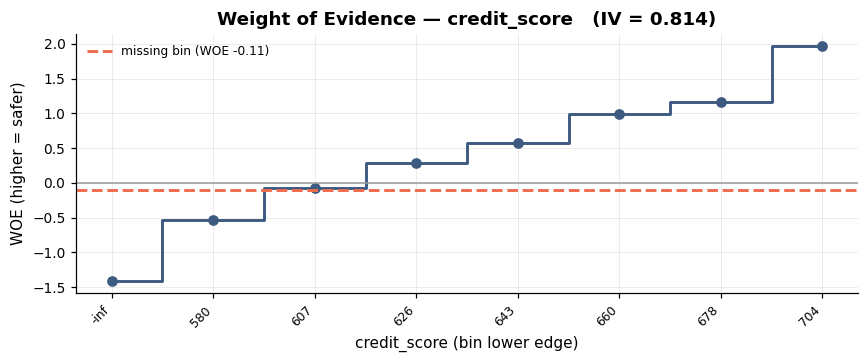

In [9]:
# The WOE curve for one feature -- this is the picture a credit risk team expects.
col = "credit_score"
curve = pd.Series(woe.woe_maps_[col]).drop("__missing__", errors="ignore")
curve.index = [iv.left if hasattr(iv, "left") else iv for iv in curve.index]
curve = curve.sort_index()

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.step(range(len(curve)), curve.to_numpy(), where="mid", marker="o")
ax.axhline(0, color="0.6", lw=1)
ax.set_xticks(range(len(curve)))
ax.set_xticklabels([f"{v:.0f}" for v in curve.index], rotation=45, ha="right", fontsize=8)
ax.set(xlabel=f"{col} (bin lower edge)", ylabel="WOE (higher = safer)",
       title=f"Weight of Evidence — {col}   (IV = {woe.iv_[col]:.3f})")
if "__missing__" in woe.woe_maps_[col]:
    ax.axhline(woe.woe_maps_[col]["__missing__"], ls="--", color="#ee6c4d",
               label=f"missing bin (WOE {woe.woe_maps_[col]['__missing__']:.2f})")
    ax.legend(fontsize=8)
plt.tight_layout()

The dashed line is what makes WOE worth the trouble: applicants with **no
bureau score** get their own evidence weight, estimated from data, rather than
being imputed to the median and pretending they are average.

In [10]:
# Does it work? The classic scorecard: WOE + logistic regression.
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cv = StratifiedKFold(5, shuffle=True, random_state=0)

standard = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median", add_indicator=True)), ("s", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False),
         make_column_selector(dtype_include=["object", "string"])),
    ])),
    ("clf", LogisticRegression(max_iter=4000, C=0.3)),
])
scorecard = Pipeline([("woe", WOEEncoder(n_bins=10)), ("clf", LogisticRegression(max_iter=2000))])
gbm = Pipeline([("prep", clone(standard.named_steps["prep"])), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06))])

pd.DataFrame([
    {"model": "one-hot + scaled logistic", "roc_auc": cross_val_score(standard, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()},
    {"model": "WOE scorecard", "roc_auc": cross_val_score(scorecard, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()},
    {"model": "gradient boosting", "roc_auc": cross_val_score(gbm, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()},
]).set_index("model").round(4)

,roc_auc
model,
one-hot + scaled logistic,0.7744
WOE scorecard,0.7674
gradient boosting,0.7467


The WOE scorecard is competitive, needs no imputation, no scaling and no
one-hot encoding, produces a model with one coefficient per feature, and comes
with an IV table the risk function already knows how to read. **That is a very
good position to be in for a model that has to be documented and defended.**

> 💼 **Consulting lens.** Ninety lines of code turned scikit-learn into a
> scorecard toolkit that fits the conventions of an existing model-risk
> process. That is usually a better engagement outcome than a model that scores
> half a point higher and requires the client to change how they govern models.

## 5. A custom classifier

`ClassifierMixin` supplies `score` (accuracy) and the classifier tag. You must
supply `classes_`, and `predict` must return values from it.

In [11]:
from sklearn.base import ClassifierMixin, MetaEstimatorMixin
from sklearn.utils.multiclass import unique_labels


class CutoffClassifier(ClassifierMixin, MetaEstimatorMixin, BaseEstimator):
    """Wrap a probabilistic classifier and apply an explicit decision threshold.

    A miniature of `TunedThresholdClassifierCV`, written out so the mechanism is
    visible. Note the mixin order: mixins first, `BaseEstimator` last, so the
    MRO resolves `__sklearn_tags__` correctly.
    """

    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator          # positional, no default: meta-estimator convention
        self.threshold = threshold

    def fit(self, X, y):
        self.classes_ = unique_labels(y)
        if len(self.classes_) != 2:
            raise ValueError("CutoffClassifier supports binary targets only")
        self.estimator_ = clone(self.estimator).fit(X, y)     # ALWAYS clone the wrapped estimator
        self.n_features_in_ = getattr(self.estimator_, "n_features_in_", np.shape(X)[1])
        if hasattr(self.estimator_, "feature_names_in_"):
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self

    def predict(self, X):
        check_is_fitted(self)
        proba = self.estimator_.predict_proba(X)[:, 1]
        return self.classes_[(proba >= self.threshold).astype(int)]

    def predict_proba(self, X):
        check_is_fitted(self)
        return self.estimator_.predict_proba(X)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        return tags

In [12]:
from sklearn.metrics import recall_score

base = Pipeline([("woe", WOEEncoder()), ("lr", LogisticRegression(max_iter=2000))])
rows = []
for t in [0.5, 0.2, 0.1, 0.07]:
    m = CutoffClassifier(base, threshold=t).fit(X.iloc[:8000], y.iloc[:8000])
    pred = m.predict(X.iloc[8000:])
    rows.append({"threshold": t, "declined_rate": round(pred.mean(), 3),
                 "recall": round(recall_score(y.iloc[8000:], pred), 3)})
pd.DataFrame(rows).set_index("threshold")

,declined_rate,recall
threshold,,
0.50,0.034,0.162
0.20,0.193,0.518
0.10,0.426,0.763
0.07,0.578,0.850


In [13]:
# Because it follows the contract, `threshold` is a searchable hyperparameter.
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(
    CutoffClassifier(base),
    {"threshold": [0.05, 0.1, 0.2, 0.5], "estimator__woe__n_bins": [5, 10]},
    cv=3, scoring="balanced_accuracy", n_jobs=-1,
).fit(X, y)
print("best:", gs.best_params_, f"-> {gs.best_score_:.4f}")
print("\nNote `estimator__woe__n_bins`: the nested path reaches through the")
print("meta-estimator into the wrapped pipeline into the WOE encoder.")

best: {'estimator__woe__n_bins': 5, 'threshold': 0.1} -> 0.6946

Note `estimator__woe__n_bins`: the nested path reaches through the
meta-estimator into the wrapped pipeline into the WOE encoder.


## 6. Custom scorers and splitters

### A scorer

`make_scorer` covers most cases (Module 08). Write the callable directly when
you need access to the fitted estimator itself.

In [14]:
from sklearn.metrics import make_scorer, roc_auc_score


def partial_auc_scorer(max_fpr=0.1):
    """AUC restricted to the low-false-positive region — the part of the curve
    an operations team with limited capacity actually lives on."""
    return make_scorer(roc_auc_score, response_method="predict_proba", max_fpr=max_fpr)


def latency_aware_scorer(estimator, X, y, penalty_per_ms=0.001):
    """A raw callable scorer: signature (estimator, X, y) -> float.
    Has access to the estimator, so it can measure inference cost."""
    from time import perf_counter

    t0 = perf_counter()
    proba = estimator.predict_proba(X)[:, 1]
    ms_per_1k = (perf_counter() - t0) / len(X) * 1e6
    return roc_auc_score(y, proba) - penalty_per_ms * ms_per_1k


from sklearn.model_selection import cross_validate

res = cross_validate(
    clone(standard), X, y, cv=3,
    scoring={"auc": "roc_auc", "partial_auc@10%fpr": partial_auc_scorer(0.1), "auc_minus_latency": latency_aware_scorer},
    n_jobs=1,
)
pd.DataFrame({k: v for k, v in res.items() if k.startswith("test_")}).mean().round(4).to_frame("mean")

,mean
test_auc,0.7744
test_partial_auc@10%fpr,0.6388
test_auc_minus_latency,0.7710


### A splitter

Module 04 pointed out that sklearn has no splitter respecting **both** time and
groups. The protocol is two methods, so writing one is straightforward.

In [15]:
class TimeSeriesGroupSplit:
    """Expanding-window splits in which no group spans train and test.

    Any group straddling the cut point is assigned wholly to training, which is
    the conservative choice: it can only shrink the test set, never leak into it.
    """

    def __init__(self, n_splits=5, gap=0):
        self.n_splits = n_splits
        self.gap = gap

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("TimeSeriesGroupSplit requires `groups`")
        n = len(X)
        order = np.arange(n)                       # X is assumed already time-ordered
        groups = np.asarray(groups)
        fold = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            cut = i * fold
            train_idx = order[: cut - self.gap]
            test_idx = order[cut: cut + fold]
            # move any group present in train out of test
            train_groups = set(groups[train_idx])
            test_idx = test_idx[~np.isin(groups[test_idx], list(train_groups))]
            if len(test_idx) == 0:
                continue
            yield train_idx, test_idx

In [16]:
from skmastery import load_card_fraud

fraud = load_card_fraud().sort_values("timestamp").reset_index(drop=True)
fX = fraud.drop(columns=["is_fraud", "timestamp"])
for c in fX.select_dtypes(include=["object", "string"]).columns:
    fX[c] = fX[c].astype("category")

splitter = TimeSeriesGroupSplit(n_splits=4)
for i, (tr, te) in enumerate(splitter.split(fX, fraud["is_fraud"], groups=fraud["card_id"])):
    overlap = set(fraud["card_id"].iloc[tr]) & set(fraud["card_id"].iloc[te])
    print(f"fold {i}: train {len(tr):6,} (rows 0–{tr.max():,})  test {len(te):5,} "
          f"(rows {te.min():,}–{te.max():,})  shared cards: {len(overlap)}")

fold 0: train 12,000 (rows 0–11,999)  test 3,103 (rows 12,002–23,992)  shared cards: 0
fold 1: train 24,000 (rows 0–23,999)  test   749 (rows 24,006–35,971)  shared cards: 0
fold 2: train 36,000 (rows 0–35,999)  test   250 (rows 36,022–47,986)  shared cards: 0
fold 3: train 48,000 (rows 0–47,999)  test    40 (rows 48,749–59,854)  shared cards: 0


**Look at the test-set sizes: 3,103 → 749 → 250 → 40.** The conservative rule
is eating the later folds. With ~9,000 cards and an expanding training window,
by fold 3 almost every card has already appeared in training, so almost nothing
survives the group filter.

That is the splitter behaving correctly and the *design* being wrong for this
data. Three honest fixes:

1. **Split on entities, not rows** — assign whole cards to train or test, then
   order within each. Appropriate when you score new cards.
2. **Use a rolling rather than expanding window** — train on the last *k*
   months only, so older cards drop out of training. Appropriate when you score
   the same cards over time, which is the realistic fraud scenario.
3. **Accept that "unseen card" is not the deployment scenario** and use a plain
   `TimeSeriesSplit` — but then say so, and never quote the score as
   performance on new customers.

The point is not that this splitter is bad. It is that **writing the splitter
forces you to state the deployment scenario precisely**, and doing that
exposes the question nobody had answered.

In [17]:
# It satisfies the protocol, so it drops straight into cross_val_score.
sc = cross_val_score(
    HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, max_iter=150),
    fX, fraud["is_fraud"], groups=fraud["card_id"], cv=splitter, scoring="average_precision", n_jobs=-1,
)
print(f"\ntime+group AP: {sc.mean():.4f} ± {sc.std():.4f}  over {len(sc)} folds")


time+group AP: 0.0164 ± 0.0132  over 4 folds


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


## 7. `__sklearn_tags__` — the modern tag API

Tags tell the library what your estimator can handle. Since 1.6 they are a
dataclass returned by `__sklearn_tags__` (the old `_get_tags` / `_more_tags`
dict API is gone). Always call `super().__sklearn_tags__()` and modify.

In [18]:
tags = Winsorizer().__sklearn_tags__()
print("estimator_type :", tags.estimator_type)
print("requires_fit   :", tags.requires_fit)
print("\ninput_tags:")
for f in ["allow_nan", "sparse", "categorical", "string", "positive_only", "two_d_array"]:
    print(f"  {f:<15}", getattr(tags.input_tags, f))
print("\ntarget_tags:")
for f in ["required", "single_output", "multi_output"]:
    print(f"  {f:<15}", getattr(tags.target_tags, f))

estimator_type : None
requires_fit   : True

input_tags:
  allow_nan       True
  sparse          False
  categorical     False
  string          False
  positive_only   False
  two_d_array     True

target_tags:
  required        False
  single_output   True
  multi_output    False


The tags that most often need setting:

| Tag | Set it when |
|---|---|
| `input_tags.allow_nan` | your estimator handles NaN itself (so `check_estimator` stops feeding it clean data only) |
| `input_tags.sparse` | you accept scipy sparse input |
| `input_tags.categorical` | you accept non-numeric columns |
| `target_tags.required` | `fit` needs `y` (supervised transformers like `WOEEncoder`) |
| `classifier_tags.multi_class` | set `False` for binary-only classifiers |
| `non_deterministic` | results vary run to run even with a fixed seed |

---
## Exercises

### Exercise 11.1 — Make three broken estimators pass

Take `BadTransformer` and fix it one rule at a time, running `check_estimator`
after each fix and recording which check started passing. Produce a table
mapping each contract rule to the check that enforces it.

Then write two more deliberately broken estimators — one that fails to reset
state on refit, one that learns during `transform` — and show which checks
catch them. (One of them is not caught. Which, and what would you write to
catch it?)

In [19]:
# Your code here.

### Exercise 11.2 — Extend the WOE encoder

Add to `WOEEncoder`:

1. **Monotonic binning** — merge adjacent bins until WOE is monotone in the
   feature. Regulators frequently require this.
2. **Cross-fitting** — like `TargetEncoder`, compute each row's WOE from folds
   that exclude it, so `fit_transform` on training data does not leak.
3. **`inverse_transform`** — map a WOE value back to its bin range, for
   reporting.
4. **A scorecard report** — convert coefficients to points (the standard
   `points = -(β·WOE + α/n) · factor + offset` formulation) and emit the table.

Verify (2) with the pure-noise test from Module 02: a unique-per-row column
must score ~0.5 AUC in cross-validation.

In [20]:
# Your code here.

### Exercise 11.3 — A resampling-aware meta-estimator

Write `ThresholdOptimizedClassifier(estimator, cost_fn, cost_fp, cv=5)` that
fits the wrapped estimator, finds the cost-minimising threshold by internal
cross-validation, refits on all data, and applies it. Support `predict`,
`predict_proba`, `decision_function`, and expose `best_threshold_`.

Make it pass `check_estimator`, then compare it head-to-head with
`TunedThresholdClassifierCV`. Where do you differ, and is your difference a bug
or a design choice?

In [21]:
# Your code here.

### Exercise 11.4 — A transformer with a fit-time budget

Write `TimeBudgetSelector(estimator, max_features, budget_seconds)` — a feature
selector that greedily adds features by marginal CV gain until either
`max_features` is reached or the time budget expires, whichever comes first.

It must be deterministic given a seed, report what it did in
`selection_log_`, and behave sensibly when the budget expires before any
feature is added. Make it pass `check_estimator`.

In [22]:
# Your code here.

### Exercise 11.5 — Package it

Turn `Winsorizer`, `WOEEncoder`, `CutoffClassifier` and `TimeSeriesGroupSplit`
into an installable package:

- `pyproject.toml`, a proper package layout, a version.
- A pytest suite using `parametrize_with_checks`.
- NumPy-style docstrings with a runnable Examples section, verified by
  `pytest --doctest-modules`.
- A README with a worked example.
- CI (GitHub Actions) running the tests on the last two sklearn versions.

This is the exercise that turns notebook code into something a team can depend
on, and it is the one most worth actually doing.

In [23]:
# Your code here.

---
## Takeaways

- `__init__` stores its arguments unmodified and validates nothing. `clone`
  depends on it, and therefore so does every cross-validation you run.
- `fit` validates, sets `n_features_in_`, stores learned state with trailing
  underscores, resets, and returns `self`.
- `transform`/`predict` call `check_is_fitted`, validate with `reset=False`,
  and learn nothing.
- `check_estimator` is the library's own conformance suite. Run it. Declare
  legitimate failures with `expected_failed_checks` rather than hiding them.
- Implementing `get_feature_names_out` gets you `set_output` support for free.
- `__sklearn_tags__` (1.6+) is how you declare NaN, sparse, categorical and
  supervised-transformer behaviour.
- A splitter is just `split()` and `get_n_splits()` — write the one your data
  needs.
- **A ninety-line WOE encoder can be worth more to a client than a model that
  scores half a point higher**, because it fits the process they already have.

**Next:** Module 12 — interpretability and fairness: producing explanations
that survive contact with a model-risk committee.